<a href="https://colab.research.google.com/github/szeeshanZ123/CODSOFT/blob/main/titanic.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [40]:
import pandas as pd

In [41]:
import numpy as np

In [42]:
import seaborn as sns

In [43]:
import matplotlib.pyplot as plt

In [44]:
df= pd.read_csv("Titanic-Dataset.csv")

In [45]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [46]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


Added CSV File

In [47]:
df.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,177
SibSp,0
Parch,0
Ticket,0
Fare,0


In [48]:
df.drop('Cabin',axis=1,inplace=True)

In [49]:
med_age=df['Age'].median()
df['Age']= df['Age'].fillna(med_age)

In [50]:
common_em=df['Embarked'].mode()[0]

df['Embarked']=df['Embarked'].fillna(common_em)

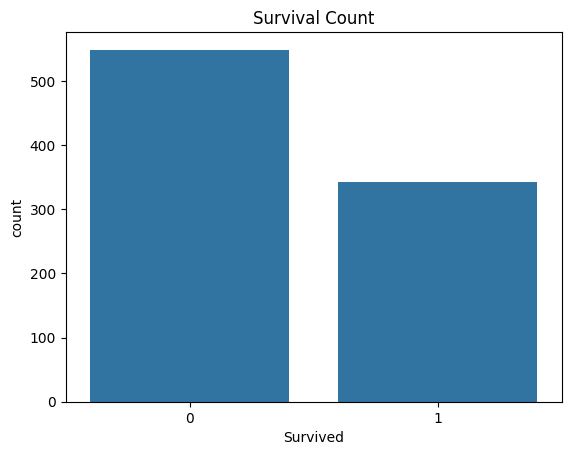

In [51]:
sns.countplot(x='Survived',data=df)
plt.title("Survival Count")
plt.show()

More people did not survive than survived

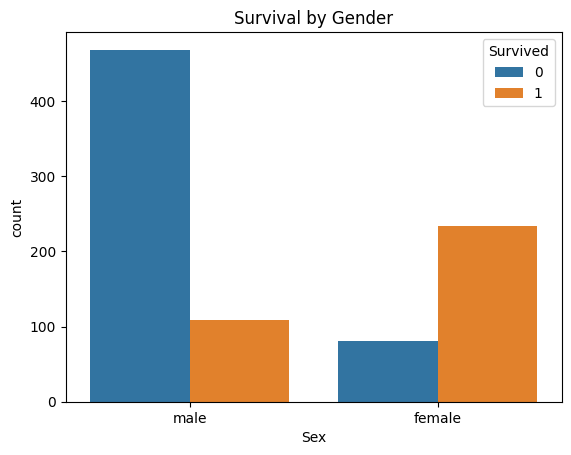

In [52]:
sns.countplot(x='Sex',hue='Survived',data=df)
plt.title("Survival by Gender")
plt.show()


Females had much hogher survival rate than Males

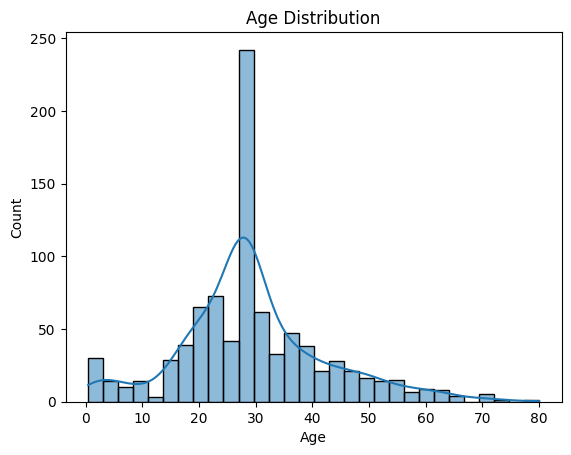

In [53]:
sns.histplot(df['Age'],kde=True)
plt.title("Age Distribution")
plt.show()

Most passengers were between 20–40 age

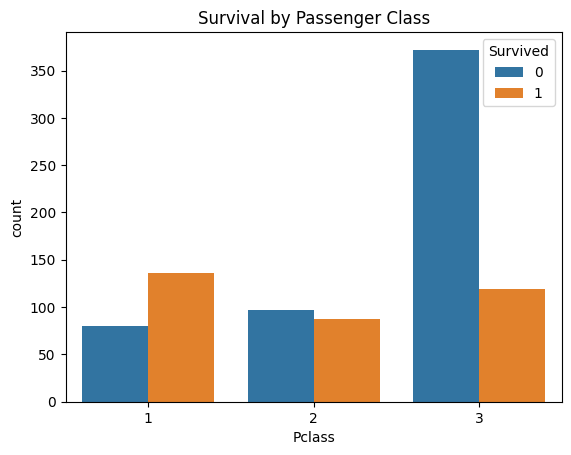

In [54]:
sns.countplot(x='Pclass',hue='Survived',data=df)
plt.title("Survival by Passenger Class")
plt.show()

Higher class(1st class)= more survival

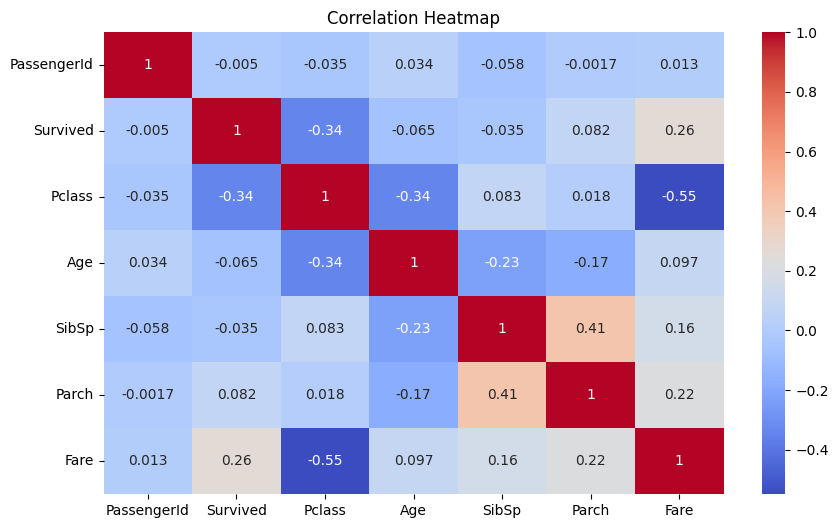

In [55]:
plt.figure(figsize=(10,6))
sns.heatmap(df.select_dtypes(include=['number']).corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

Starting ML Part

In [56]:
df['Sex']=df['Sex'].map({'male':0,'female': 1})
df=pd.get_dummies(df,columns=['Embarked'],drop_first=True)

In [57]:
X=df[['Pclass','Sex','Age','SibSp','Parch','Fare']]
y=df['Survived']

In [58]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(
    X,y,test_size=0.2,random_state=42
)

In [59]:
from sklearn.linear_model import LogisticRegression
model=LogisticRegression()
model.fit(X_train,y_train)

LogisticRegression()

In [60]:
y_pred = model.predict(X_test)

In [61]:
from sklearn.metrics import accuracy_score
accuracy = accuracy_score(y_test,y_pred)
print("Model Accuracy",accuracy)

Model Accuracy 0.8100558659217877


In [62]:
from sklearn.metrics import confusion_matrix
cm=confusion_matrix(y_test,y_pred)
print(cm)

[[92 13]
 [21 53]]


In [63]:
from sklearn.metrics import classification_report
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.81      0.88      0.84       105
           1       0.80      0.72      0.76        74

    accuracy                           0.81       179
   macro avg       0.81      0.80      0.80       179
weighted avg       0.81      0.81      0.81       179



The Logistic Regression model achieved an accuracy of approximately 81%. The Analysis showed that Gender ,Passsenger class ,and fare significantly influenced survival chances .